In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# load_data
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Names of classes (10 types of clothing)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nThe data was uploaded successfully!")
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("Size of each image:", x_train.shape[1], "x", x_train.shape[2])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

The data was uploaded successfully!
Number of training images: 60000
Number of test images: 10000
Size of each image: 28 x 28


======> first 10 labels: [9 0 0 3 0 2 7 2 5 5] <====== 
 


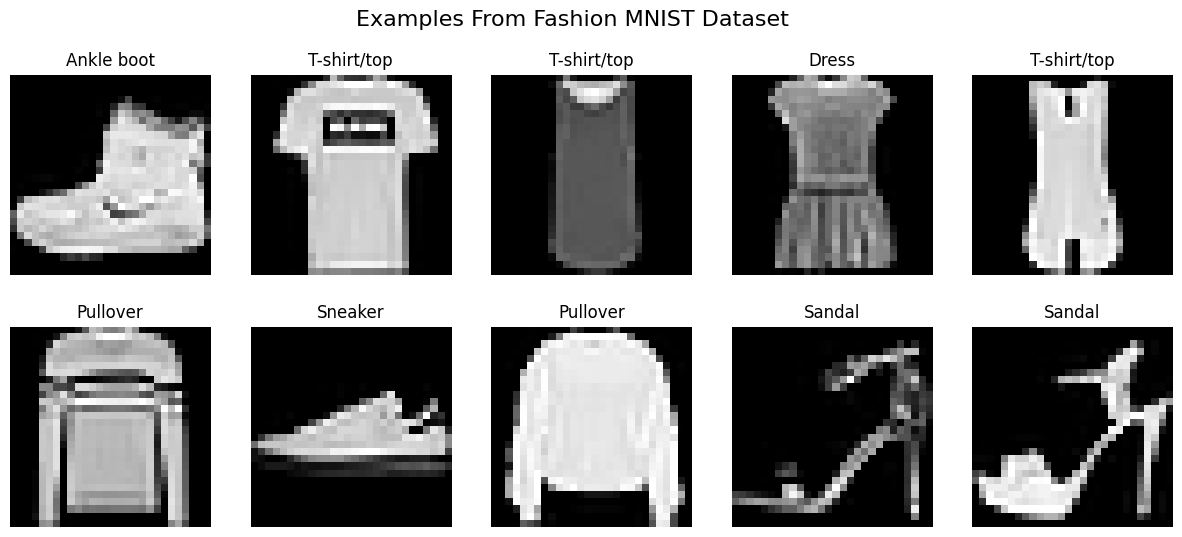

In [ ]:
# Print the first 10 labels.
print("======> first 10 labels:", y_train[:10] ,"<====== \n ")

#Show 10 images from the data.
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Examples From Fashion MNIST Dataset", fontsize=16)
plt.show()

In [ ]:
# ====================== Preprocessing ======================
# 1. Normalization (Divide by 255 to make the numbers between 0 and 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 2. Add the Channel dimension because CNN needs 4 dimensions: (no. of images, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("     =====> The data was successfully processed <=====\n")
print("-> The x_train shape after modification:", x_train.shape)
print("-> The x_test shape after modification:", x_test.shape, "\n")

# ====================== Building a CNN model ======================
model = tf.keras.Sequential([
    # First layer: Convolution + Pooling
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Second layer: Convolution + Pooling
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Convert images to vector
    tf.keras.layers.Flatten(),

    # Fully Connected layer (Dense)
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),        #To avoid overfitting
    tf.keras.layers.Dense(10, activation='softmax')   # 10 classes
])

# Model assembly
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

     =====> The data was successfully processed <=====

-> The x_train shape after modification: (60000, 28, 28, 1)
-> The x_test shape after modification: (10000, 28, 28, 1) 



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,754 (1.27 MB)

 Trainable params: 330,858 (1.26 MB)

 Non-trainable params: 896 (3.50 KB)

Training is in progress.....
Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 184ms/step - accuracy: 0.6895 - loss: 0.9239 - val_accuracy: 0.8169 - val_loss: 0.4946
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 136s 176ms/step - accuracy: 0.8000 - loss: 0.5602 - val_accuracy: 0.8514 - val_loss: 0.4070
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 175ms/step - accuracy: 0.8317 - loss: 0.4734 - val_accuracy: 0.8658 - val_loss: 0.3645
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 173ms/step - accuracy: 0.8511 - loss: 0.4177 - val_accuracy: 0.8853 - val_loss: 0.3193
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 131s 175ms/step - accuracy: 0.8611 - loss: 0.3855 - val_accuracy: 0.8882 - val_loss: 0.3068
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 132s 177ms/step - accuracy: 0.8716 - loss: 0.3585 - val_accuracy: 0.8973 - val_loss: 0.2832
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 176ms/step - accuracy: 0.8807 - loss: 0.3341 - val_accuracy: 0.9018 - val_loss: 0.2702
Epoch 8/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 131s 17

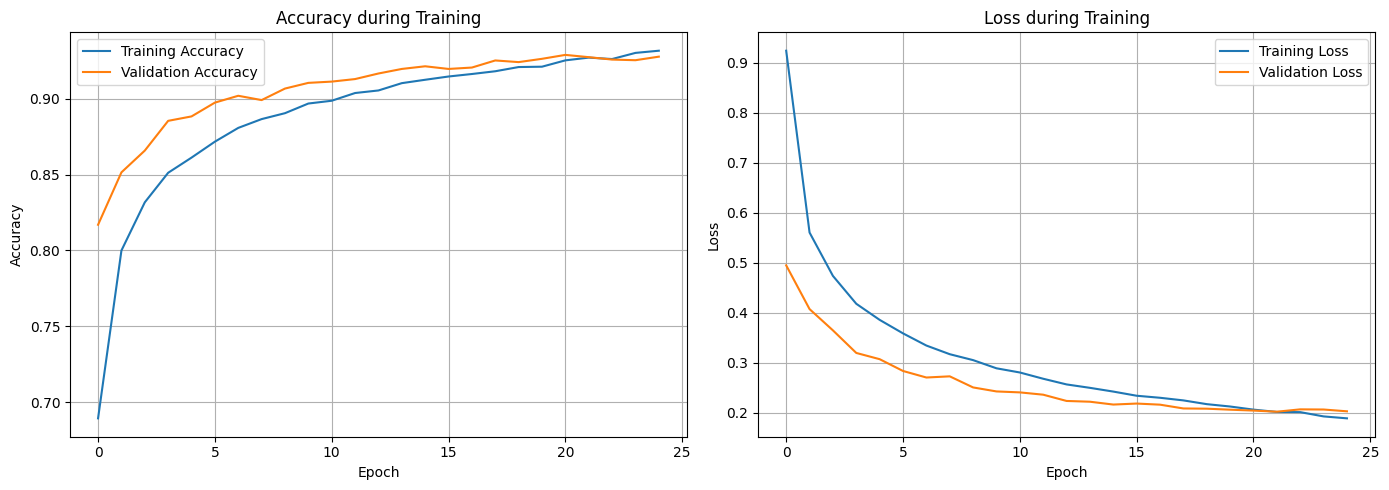


Final accuracy of test data: 92.29%
Loss: 0.2208


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# ====================== Training ======================
print("Training is in progress.....")

history = model.fit(
    x_train,
    y_train,
    epochs=25,              # No. of cycles
    batch_size=64,          # batch size
    validation_split=0.2,   # 20% of the data is for validation.
    callbacks=[early_stop],
    verbose=1               # print each Epoch's progress
)

print("\nThe training was successful!")

# ====================== Drawing training curves ======================
plt.figure(figsize=(14, 5))

# Drawing Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Drawing Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ====================== Evaluating the model on test data ======================
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\n" + "="*50)
print(f"Final accuracy of test data: {test_acc * 100:.2f}%")
print(f"Loss: {test_loss:.4f}")
print("="*50)


The model was saved as: fashion_mnist_cnn_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step


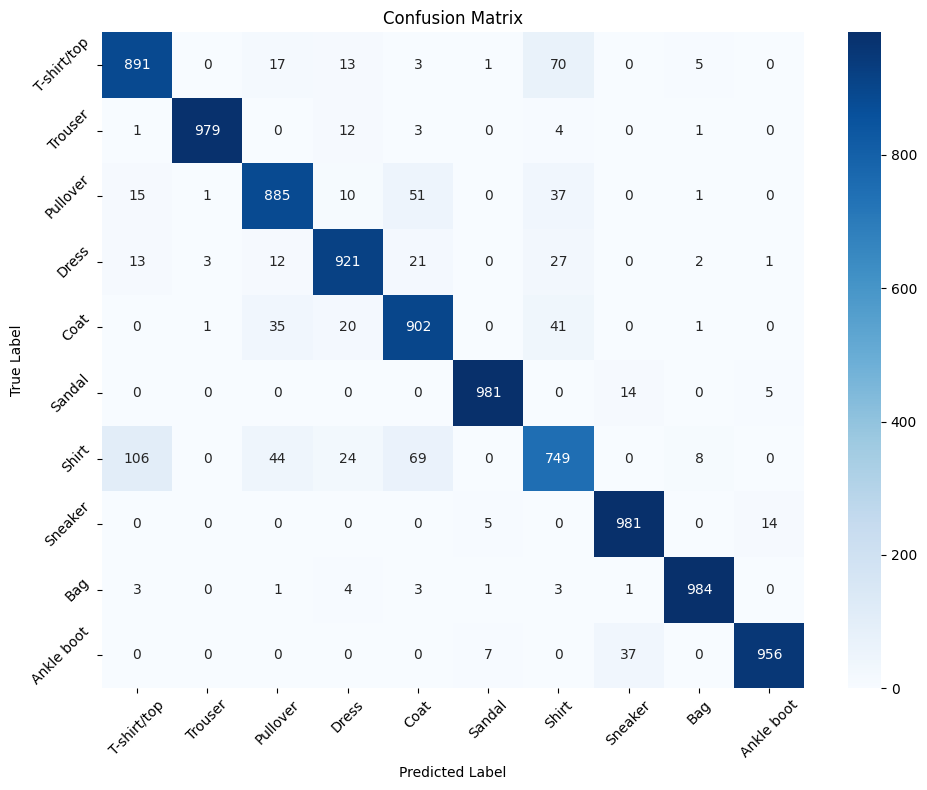


Detailed classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.89      0.88      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.89      0.89      0.89      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.86      0.90      0.88      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.80      0.75      0.78      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Final accuracy: 92.29%


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== 1. Save the model ======================
model.save('fashion_mnist_cnn_model.h5')
print("The model was saved as: fashion_mnist_cnn_model.h5")

# ====================== 2. Prediction based on test data ======================
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ====================== 3. Confusion Matrix ======================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# ====================== 4. Classification Report ======================
print("\n" + "="*60)
print("Detailed classification report:")
print("="*60)
print(classification_report(y_test, y_pred_classes, target_names=class_names))
print("="*60)

# print the final accuracy:
print(f"Final accuracy: {test_acc * 100:.2f}%")

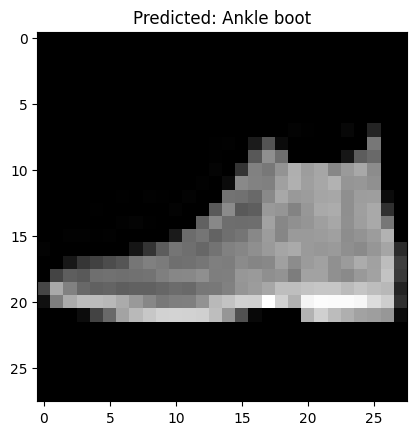

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {class_names[y_pred_classes[0]]}")
plt.show()